# Beispiel: Nährstoffzusatz und Biomasseproduktion

Dieses Notebook demonstriert den Unterschied zwischen einem ungepaarten Zweistichproben-t-Test und einem gepaarten t-Test.

In [16]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats

## Daten
Ein Biotechnologieunternehmen untersucht den Einfluss eines Nährstoffzusatzes auf die Biomasseproduktion.

In [13]:
df = pd.DataFrame({
    "Ohne Zusatz": [12,20,15,26,18,10],
    "Mit Zusatz": [14,23,17,27,20,12]
})

df

,Ohne Zusatz,Mit Zusatz
0,12,14
1,20,23
2,15,17
3,26,27
4,18,20
5,10,12


In [15]:
df_long = df.melt(
    value_vars=["Ohne Zusatz", "Mit Zusatz"],
    var_name="Typ",
    value_name="Biomasse"
)

df_long

,Typ,Biomasse
0,Ohne Zusatz,12
1,Ohne Zusatz,20
2,Ohne Zusatz,15
3,Ohne Zusatz,26
4,Ohne Zusatz,18
5,Ohne Zusatz,10
6,Mit Zusatz,14
7,Mit Zusatz,23
8,Mit Zusatz,17
9,Mit Zusatz,27


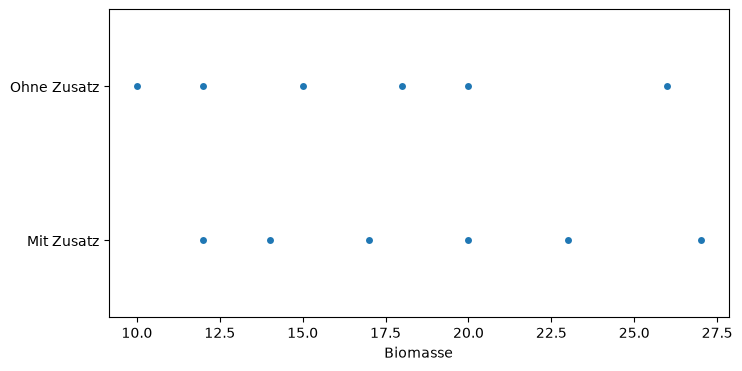

In [17]:
plt.figure(figsize=(8, 4))

sns.stripplot(
    data=df_long,
    x="Biomasse",
    y="Typ",
    jitter=False
)

plt.xlabel("Biomasse")
plt.ylabel("")

plt.show()

In [18]:
df.describe()

,Ohne Zusatz,Mit Zusatz
count,6.000000,6.000000
mean,16.833333,18.833333
std,5.810909,5.636193
min,10.000000,12.000000
25%,12.750000,14.750000
50%,16.500000,18.500000
75%,19.500000,22.250000
max,26.000000,27.000000


## 1. Auswertung als unabhängige Stichproben

In [33]:
# Daten
y1 = df["Ohne Zusatz"]
y2 = df["Mit Zusatz"]

# Kennzahlen
n1 = len(y1)
n2 = len(y2)

mean1 = y1.mean()
mean2 = y2.mean()

var1 = y1.var(ddof=1)
var2 = y2.var(ddof=1)

# Difference in means
mean_diff = mean1 - mean2

# pooled variance
sp2 = ((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2)
sp = np.sqrt(sp2)

# standard error
se = sp * np.sqrt(1/n1 + 1/n2)

# degrees of freedom
dfree = n1 + n2 - 2

# critical t value
tcrit = stats.t.ppf(0.975, dfree)

# confidence interval
ci_lower = mean_diff - tcrit * se
ci_upper = mean_diff + tcrit * se

# t-test
t_stat, p_value = stats.ttest_ind(
    y1,
    y2,
    equal_var=True
)
print(f"Ohne Zusatz mean      : {mean1:.2f}")
print(f"Mit Zusatz mean       : {mean2:.2f}")
print(f"Mean difference       = {mean_diff:.3f}")

print("-" * 30)


print("Two-Sample t-Test")
print("-" * 30)
print(f"t-statistic        = {t_stat:.3f}")
print(f"degrees of freedom = {len(df)*2-2}")
print(f"p-value            = {p_value:.4f}")
print(f"95% CI             = ({ci_lower:.3f}, {ci_upper:.3f})")

if p_value < 0.05:
    print("\nConclusion: Reject H0 at α = 0.05")
else:
    print("\nConclusion: Do not reject H0 at α = 0.05")

Ohne Zusatz mean      : 16.83
Mit Zusatz mean       : 18.83
Mean difference       = -2.000
------------------------------
Two-Sample t-Test
------------------------------
t-statistic        = -0.605
degrees of freedom = 10
p-value            = 0.5586
95% CI             = (-9.364, 5.364)

Conclusion: Do not reject H0 at α = 0.05


**Interpretation:** Der Effekt erscheint bei einer Auswertung als unabhängige Stichproben nicht signifikant.

## Zusätzliche Information
Tatsächlich wurde jede Kultur in zwei Teilkulturen aufgeteilt. Die Beobachtungen sind also gepaart.

In [24]:
df["d"] = df["Mit Zusatz"] - df["Ohne Zusatz"]

df

,Ohne Zusatz,Mit Zusatz,d
0,12,14,2
1,20,23,3
2,15,17,2
3,26,27,1
4,18,20,2
5,10,12,2


## 2. Gepaarter t-Test

In [30]:
d = df["Mit Zusatz"] - df["Ohne Zusatz"]

result = stats.ttest_rel(
    df["Mit Zusatz"],
    df["Ohne Zusatz"]
)

mean_diff = d.mean()
sd = d.std(ddof=1)

se = sd / np.sqrt(len(d))

tcrit = stats.t.ppf(0.975, len(d)-1)

ci_lower = mean_diff - tcrit * se
ci_upper = mean_diff + tcrit * se

print("Paired t-Test")
print("-" * 30)
print(f"Mean difference = {mean_diff:.3f}")
print(f"t-statistic     = {result.statistic:.3f}")
print(f"df              = {len(d)-1}")
print(f"p-value         = {result.pvalue:.4f}")
print(f"95% CI          = ({ci_lower:.3f}, {ci_upper:.3f})")

Paired t-Test
------------------------------
Mean difference = 2.000
t-statistic     = 7.746
df              = 5
p-value         = 0.0006
95% CI          = (1.336, 2.664)


## Fazit
Die gleichen Daten führen zu unterschiedlichen Schlussfolgerungen, sobald die Paarstruktur der Beobachtungen berücksichtigt wird. Dies motiviert die Blockbildung und den gepaarten t-Test.